In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import MDAnalysis

import os
import tqdm


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/TPRParser.py:161: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [2]:
# min dist

def min_dist(Traj,pairs):
    distt_ls=[]
    total_frames=len(Traj.trajectory)

    for t in tqdm.tqdm(Traj.trajectory):
        #selecting all the heavy atoms 
        sel1=Traj.select_atoms('resid %d and not type H'%pairs[0])
        sel2=Traj.select_atoms('resid %d and not type H'%pairs[1])
        dist_ls=[]
        for i in sel1.atoms:
            for j in sel2.atoms:

                pos_1=np.array(i.position)  
                pos_2=np.array(j.position)

                dist=np.linalg.norm(pos_1 - pos_2)
                dist_ls.append(dist)
        distt_ls.append(min(dist_ls))
    return(distt_ls)
    print('Done for %s'%Traj.trajectory.filename)

req_pairs=[(64,89)]


In [3]:
prefix_path='../../../LC3_MAIN_TRAJECTORIES/PROTEIN_ONLY_FITTED'

#UNB WT
u_unbound_ER_S1 = MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM1_dt1000.pdb"%prefix_path)
u_unbound_ER_S2 =MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM2_dt1000.pdb"%prefix_path)
u_unbound_ER_S3=MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM3_dt1000.pdb"%prefix_path)


In [4]:
u_unbound_ER_MUT1=MDAnalysis.Universe('/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/M1_M2_in_silico_mutations_fitted/M1_ER_concat_compact_center_fitted_0ns.gro',
                                          '/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/M1_M2_in_silico_mutations_fitted/M1_ER_concat_compact_center_fitted_dt1000.xtc')
u_unbound_ER_MUT2=MDAnalysis.Universe('/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/M1_M2_in_silico_mutations_fitted/M2_ER_concat_compact_center_fitted_0ns.gro',
                                         '/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/M1_M2_in_silico_mutations_fitted/M2_ER_concat_compact_center_fitted_dt1000.xtc')



In [5]:
wt_unb_lc3b_s1=min_dist(u_unbound_ER_S1, [64,89])
wt_unb_lc3b_s2=min_dist(u_unbound_ER_S2, [64,89])
wt_unb_lc3b_s3=min_dist(u_unbound_ER_S3, [64,89])

mut_m1=min_dist(u_unbound_ER_MUT1, [64,89])
mut_m2=min_dist(u_unbound_ER_MUT2, [64,89])

100%|████████████████████████████| 1001/1001 [00:00<00:00, 1609.31it/s]


In [6]:
dist_df=pd.DataFrame()
for fil in os.listdir('/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/traj_data_fitted/'):
    if fil.endswith('.gro'):
        print(fil)
        fil_name=fil.replace('_0ns.gro','')
        mut_name=fil_name.replace('_ER_concat_compact_center_fitted','')
        struc_fil=MDAnalysis.Universe('/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/traj_data_fitted/%s'%fil,
                                      '/Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/traj_data_fitted/%s_dt1000.xtc'%fil_name
                                      )
        
        dist_df[mut_name]=min_dist(struc_fil, [64,89])

S61K_S90D_ER_concat_compact_center_fitted_0ns.gro


100%|████████████████████████████| 1001/1001 [00:00<00:00, 1797.53it/s]


M60K_M88D_ER_concat_compact_center_fitted_0ns.gro


100%|████████████████████████████| 1001/1001 [00:00<00:00, 1811.16it/s]


A75D_ER_concat_compact_center_fitted_0ns.gro


...

100%|████████████████████████████| 1001/1001 [00:00<00:00, 1702.76it/s]


I64F_ER_concat_compact_center_fitted_0ns.gro


100%|████████████████████████████| 1001/1001 [00:00<00:00, 1569.09it/s]


._S90A_ER_concat_compact_center_fitted_0ns.gro


ValueError: Failed to construct topology from file /Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/traj_data_fitted/._S90A_ER_concat_compact_center_fitted_0ns.gro with parser <class 'MDAnalysis.topology.GROParser.GROParser'>.
Error: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte

In [ ]:
# ls -ltr /Volumes/PortableSSD/LC3B_DATA_/new_test_mutant_sims/

In [7]:
dist_df['WT_S1']=wt_unb_lc3b_s1
dist_df['WT_S2']=wt_unb_lc3b_s2
dist_df['WT_S3']=wt_unb_lc3b_s3
dist_df['M1']=mut_m1
dist_df['M2']=mut_m2
dist_df

,S61K_S90D,M60K_M88D,A75D,I64T_L81M,A75K,L5_TRIPLE_A75D_N76E_F79D,N76A_F79A,L81M,S90A,M60A,I64F,WT_S1,WT_S2,WT_S3,M1,M2
0,6.735556,6.396013,6.833231,8.405221,6.671124,6.859378,6.781098,6.762177,6.797336,7.061312,7.412190,6.528200,6.528200,6.533063,6.497362,2.645773
1,3.821111,7.907983,3.905135,3.661267,4.128196,4.100197,4.179356,3.815944,3.352400,3.767265,3.914653,3.720067,3.970280,3.657006,3.627313,2.638065
2,3.686371,8.036479,3.794572,3.704657,3.925101,3.772701,3.975560,3.817616,4.181015,3.534884,3.670338,3.612264,3.943936,3.837942,3.937783,2.590637
3,3.604554,7.277767,3.510220,4.164779,4.071132,3.784412,3.972632,3.878051,4.405361,4.263821,4.141090,3.892608,4.148665,3.802667,3.879500,2.706012
4,4.485865,7.283154,3.532389,3.622655,5.358741,3.159019,4.127834,3.847414,4.098498,3.827337,3.752388,3.848300,3.857480,3.445953,3.649740,2.859475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,4.131854,14.280107,4.136543,6.596760,3.702183,3.761565,4.548524,4.126083,3.744233,6.269491,3.713290,3.794288,3.946993,3.442802,10.128308,2.907522
997,3.696213,14.762506,4.218606,6.808775,4.150099,4.009316,3.500786,3.714971,3.557992,4.998511,3.646655,3.656476,3.933356,3.474825,10.055810,2.626441
998,3.583893,15.732273,4.002368,5.921030,4.052765,3.799291,3.503983,4.230947,3.912037,5.441260,3.779483,3.930517,3.536413,3.308141,9.497804,2.800806
999,3.966894,15.241535,3.799699,6.658085,3.929231,3.776795,3.836936,3.394911,4.122675,4.492982,3.901869,3.620377,3.851703,3.856451,8.594193,3.088789


In [8]:
# reorder the mutants and WT

dist_df=dist_df[['M1','M2','A75D','A75K','M60K_M88D','S61K_S90D','L5_TRIPLE_A75D_N76E_F79D',
                'N76A_F79A','M60A','S90A','I64F','L81M','I64T_L81M','WT_S1', 'WT_S2', 'WT_S3']]

dist_df_ord_=dist_df[['A75K', 'M1', 'S90A', 'N76A_F79A', 'M60A', 'L81M',
                'A75D','M2','S61K_S90D','L5_TRIPLE_A75D_N76E_F79D','I64F','M60K_M88D','I64T_L81M',
                     'WT_S1', 'WT_S2', 'WT_S3']]

dist_df_ord_.columns=['A75K', 'I64D_V89P_V91D', 'S90A', 'N76A_F79A', 'M60A', 'L81M',
                'A75D','I64K_V89D_V91F','S61K_S90D','A75D_N76E_F79D','I64F','M60K_M88D','I64T_L81M',
                     'WT_S1', 'WT_S2', 'WT_S3']

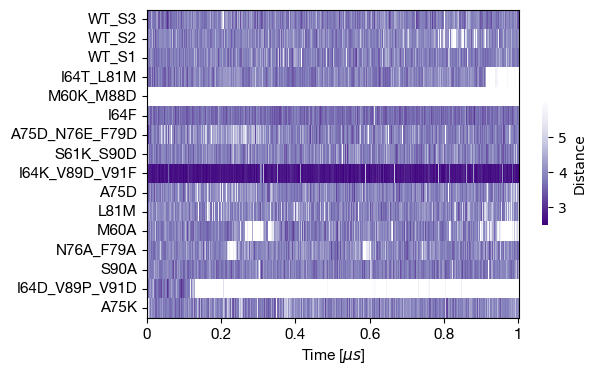

In [10]:

font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 11
        }
rs={'family':'helvetica neue',
    'size':14
   }


fig, ax = plt.subplots(figsize=(6, 4))


mask = dist_df_ord_.T > 6

sns.heatmap(dist_df_ord_.T, cmap='Purples_r',
           mask=mask, cbar_kws={'shrink':0.4, 'label':'Distance'})

ax.set_yticks([i+0.5 for i in range(len(dist_df_ord_.columns))],
              labels=[i for i in dist_df_ord_.columns],)
ax.set_yticklabels([i for i in dist_df_ord_.columns],
                   fontdict=font)

ax.set_xticks([0,200,400,600,800,1000],
              labels=[0,0.2,0.4,0.6,0.8,1], rotation=0)
ax.set_xticklabels([0,0.2,0.4,0.6,0.8,1],fontdict=font, )

# ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.set_axisbelow(True)
ax.invert_yaxis()

# ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
# ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)


ax.set_xlabel('Time [$\mu s$]', fontdict=font)
#ax.set_ylabel('Mutants', fontdict=font)

# sns.heatmap(lipid_vic_mat_df.to_numpy(),cmap="Purples",cbar=True)

plt.savefig('../../plots/TRIAD_MUTANT_CANDIDATES/64_89_min_dist_heatmap_MUTANTS_WT_reordered_n.png',
            dpi=450, bbox_inches='tight',
           transparent=True,)

In [ ]:
dist_df_ord_

In [16]:
dist_df_ord_.to_csv("../../../LC3_paper_data_files_for_source_data_comp/TRIAD_DISTANCE_DAT.csv")

In [ ]:

font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 11
        }
rs={'family':'helvetica neue',
    'size':14
   }


fig, ax = plt.subplots(figsize=(2, 4))


mask = dist_df_ord_.T > 6

sns.heatmap(dist_df_ord_.T, cmap='Purples_r',
           mask=mask, cbar_kws={'shrink':0.4, 'label':'Distance'})

ax.set_yticks([i+0.5 for i in range(len(dist_df_ord_.columns))],
              labels=[i for i in dist_df_ord_.columns],)
ax.set_yticklabels([i for i in dist_df_ord_.columns],
                   fontdict=font)

ax.set_xticks([0,200,400,600,800,1000],
              labels=[0,200,400,600,800,1000])
ax.set_xticklabels([0,200,400,600,800,1000],fontdict=font)

# ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.set_axisbelow(True)

# ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
# ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)


ax.set_xlabel('Time(ns)', fontdict=font)
#ax.set_ylabel('Mutants', fontdict=font)

# sns.heatmap(lipid_vic_mat_df.to_numpy(),cmap="Purples",cbar=True)

plt.savefig('../../plots/TRIAD_MUTANT_CANDIDATES/64_89_min_dist_heatmap_MUTANTS_WT_reordered_SHORTER.png',
            dpi=450, bbox_inches='tight',
           transparent=True,)

In [7]:
dist_df_ord_WT=dist_df[['WT_S1','WT_S2','WT_S3']]
dist_df_ord_WT

KeyError: "None of [Index(['WT_S1', 'WT_S2', 'WT_S3'], dtype='object')] are in the [columns]"

In [8]:

# font = {'family':'helvetica neue',
#         'color':  'black',
#         'weight': 'bold',
#         'size': 11
#         }
# rs={'family':'helvetica neue',
#     'size':14
#    }


# fig, ax = plt.subplots(figsize=(6, 2))


# mask = dist_df_ord_WT.T > 6

# sns.heatmap(dist_df_ord_WT.T, cmap='Purples_r',
#            mask=mask, cbar_kws={'shrink':0.4, 'label':'Distance'})

# ax.set_yticks([i+0.5 for i in range(len(dist_df_ord_WT.columns))],
#               labels=[i for i in dist_df_ord_WT.columns],rotation=0)
# ax.set_yticklabels([i for i in dist_df_ord_WT.columns],
#                    fontdict=font)

# ax.set_xticks([0,200,400,600,800,1000],
#               labels=[0,200,400,600,800,1000])
# ax.set_xticklabels([0,200,400,600,800,1000],fontdict=font)

# # ax.tick_params(labelsize=10)
# ax.spines['top'].set_visible(True)
# ax.spines['right'].set_visible(True)
# ax.spines['bottom'].set_visible(True)
# ax.spines['left'].set_visible(True)
# ax.set_axisbelow(True)

# # ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
# # ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)


# ax.set_xlabel('Time(ns)', fontdict=font)
# ax.set_ylabel('WT', fontdict=font)

# # sns.heatmap(lipid_vic_mat_df.to_numpy(),cmap="Purples",cbar=True)

# # plt.savefig('traj_data_fitted/64_89_min_dist_heatmap_reordered.png',dpi=450, bbox_inches='tight',
# #            transparent=True,)

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


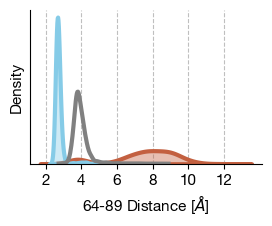

In [9]:
font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 11
        }
rs={'family':'helvetica neue',
    'size':14
   }

fig, ax = plt.subplots(figsize=(3, 2))


sns.kdeplot(wt_unb_lc3b_s1+wt_unb_lc3b_s2+wt_unb_lc3b_s3, lw=3, color="gray")
# sns.kdeplot(wt_unb_lc3b_s2)
# sns.kdeplot(wt_unb_lc3b_s3)

sns.kdeplot(mut_m1, lw=3, fill=True, color="#C36040", alpha=0.4)
sns.kdeplot(mut_m2, lw=3,fill=True, color="#85CBE7", alpha=0.4)



ax.set_xticks([2,4,6,8,10,12],
              labels=[2,4,6,8,10,12])
ax.set_xticklabels([2,4,6,8,10,12],fontdict=font)

ax.set_yticks([])

# ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.set_axisbelow(True)

ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)


ax.set_xlabel('64-89 Distance [$\\AA$]', fontdict=font)
ax.set_ylabel('Density', fontdict=font)

plt.savefig("../../plots/TRIAD_MUTANT_CANDIDATES/64_89_min_dist_KDEPLOT_wt_m1_m2.png", 
           bbox_inches='tight', transparent=True, dpi=450)

In [10]:
triad_dist_track_df=pd.DataFrame()
triad_dist_track_df["WT_UNB_S1"]=wt_unb_lc3b_s1
triad_dist_track_df["WT_UNB_S2"]=wt_unb_lc3b_s2
triad_dist_track_df["WT_UNB_S3"]=wt_unb_lc3b_s3

triad_dist_track_df["M1"]=mut_m1
triad_dist_track_df["M2"]=mut_m2
triad_dist_track_df

,WT_UNB_S1,WT_UNB_S2,WT_UNB_S3,M1,M2
0,6.528200,6.528200,6.533063,6.497362,2.645773
1,3.720067,3.970280,3.657006,3.627313,2.638065
2,3.612264,3.943936,3.837942,3.937783,2.590637
3,3.892608,4.148665,3.802667,3.879500,2.706012
4,3.848300,3.857480,3.445953,3.649740,2.859475
...,...,...,...,...,...
996,3.794288,3.946993,3.442802,10.128308,2.907522
997,3.656476,3.933356,3.474825,10.055810,2.626441
998,3.930517,3.536413,3.308141,9.497804,2.800806
999,3.620377,3.851703,3.856451,8.594193,3.088789


In [11]:
# triad_dist_track_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/triad_dist_track_WT_M1_M2.csv")

In [13]:
np.mean(triad_dist_track_df['M1']), np.std(triad_dist_track_df['M1'])

(7.547389, 1.7695078)

In [14]:
np.mean(triad_dist_track_df['M2']), np.std(triad_dist_track_df['M2'])

(2.7578075, 0.35680383)